# Project 1: Retail Sales Exploratory Data Analysis

**Authors:** Abigail Keegan, Michelle Ng Du

**Course:** CS 667 Practical Data Science, Pace University

## Abstract

An exploratory data analysis of a synthetic retail sales dataset of 1,000 transactions. Walks through data quality checks, time-series analysis of sales trends, seasonality detection via heatmaps, outlier identification using both IQR and Isolation Forest, customer demographic analysis, feature engineering, log transformation, and feature importance via correlation analysis and PCA.

**Dataset:** `retail_sales.csv`

## Column Reference

| Column | Description |
|---|---|
| Transaction ID | Unique identifier for each transaction |
| Date | Date the transaction occurred |
| Customer ID | Unique identifier for each customer |
| Gender | Customer gender (Male/Female) |
| Age | Customer age |
| Product Category | Category of purchased product (Electronics, Clothing, Beauty) |
| Quantity | Number of units purchased |
| Price per Unit | Price of one unit |
| Total Amount | Total monetary value of the transaction |

## Workflow

1. Select dataset
2. Basic EDA: understand the data's shape, content, and quality. Check for missing values, duplicates, and general statistics.
3. Advanced EDA: visualize relationships, identify correlations, and detect anomalies via time-series and feature distribution analysis.
4. Feature engineering: create meaningful new features from EDA insights.
5. Clean and transform the data: handle missing data, outliers, and skewness via log transformation.
6. Evaluate features: use correlation and PCA to identify the most relevant features for a potential model.
7. Summary: document findings, business recommendations, and additional data needs.

---
## Step 1 - Select Dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.float_format', '{:,.2f}'.format)

df = pd.read_csv('../data/retail_sales.csv')
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,11/24/2023,CUST001,Male,34,Beauty,3,50,150
1,2,2/27/2023,CUST002,Female,26,Clothing,2,500,1000
2,3,1/13/2023,CUST003,Male,50,Electronics,1,30,30
3,4,5/21/2023,CUST004,Male,37,Clothing,1,500,500
4,5,5/6/2023,CUST005,Male,30,Beauty,2,50,100


---
## Step 2 - Basic EDA

Understand the data's shape, content, and quality. Check
for missing values, duplicates, and general statistics.


In [2]:
print(f"Shape: {df.shape}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

Shape: (1000, 9)

Data Types:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicate Rows: 0


In [3]:
# Unique values for non-ID columns
for col in df:
    if col not in ['Transaction ID', 'Customer ID', 'Date']:
        print(col, df[col].unique())

Gender ['Male' 'Female']
Age [34 26 50 37 30 45 46 63 52 23 35 22 64 42 19 27 47 62 18 49 28 38 43 39
 44 51 58 48 55 20 40 54 36 31 21 57 25 56 29 61 32 41 59 60 33 53 24]
Product Category ['Beauty' 'Clothing' 'Electronics']
Quantity [3 2 1 4]
Price per Unit [ 50 500  30  25 300]
Total Amount [ 150 1000   30  500  100   50  600  200   75 1500  120 2000  900  300
 1200   90   25   60]


In [4]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,"1,000.00","1,000.00","1,000.00","1,000.00","1,000.00"
mean,500.50,41.39,2.51,179.89,456.00
std,288.82,13.68,1.13,189.68,560.00
min,1.00,18.00,1.00,25.00,25.00
25%,250.75,29.00,1.00,30.00,60.00
50%,500.50,42.00,3.00,50.00,135.00
75%,750.25,53.00,4.00,300.00,900.00
max,"1,000.00",64.00,4.00,500.00,"2,000.00"


**Findings - Step 2:**
- 1,000 rows, 9 columns, no missing values, no duplicates.
- `Total Amount` ranges 25 to 2,000, mean 456, std 560. This is a wide spread driven by 5 discrete price tiers (25, 30, 50, 300, 500).
- `Quantity` ranges 1 to 4; mean 2.51.
- `Age` ranges 18 to 64; mean 41.
- Price per unit takes only 5 values: 25, 30, 50, 300, 500.
- Gender and product categories are balanced across the dataset.

---
## Step 3 - Advanced EDA

Visualize relationships, identify correlations, and detect anomalies via time-series and feature distribution analysis.

In [5]:
# Parse dates, sort, extract time components
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
df = df.sort_values('Date').reset_index(drop=True)

df['Month']     = df['Date'].dt.month
df['MonthName'] = df['Date'].dt.month_name()
df['Quarter']   = df['Date'].dt.quarter
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['DayName']   = df['Date'].dt.day_name()

# Daily aggregated sales used throughout Step 3
daily_sales = df.groupby(['Date', 'DayOfWeek'])['Total Amount'].sum().reset_index()
daily_sales.columns = ['Date', 'DayOfWeek', 'Daily_Total']

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()} ({len(df)} transactions)")

Date range: 2023-01-01 to 2024-01-01 (1000 transactions)


### 3a. Sales Trends Over Time

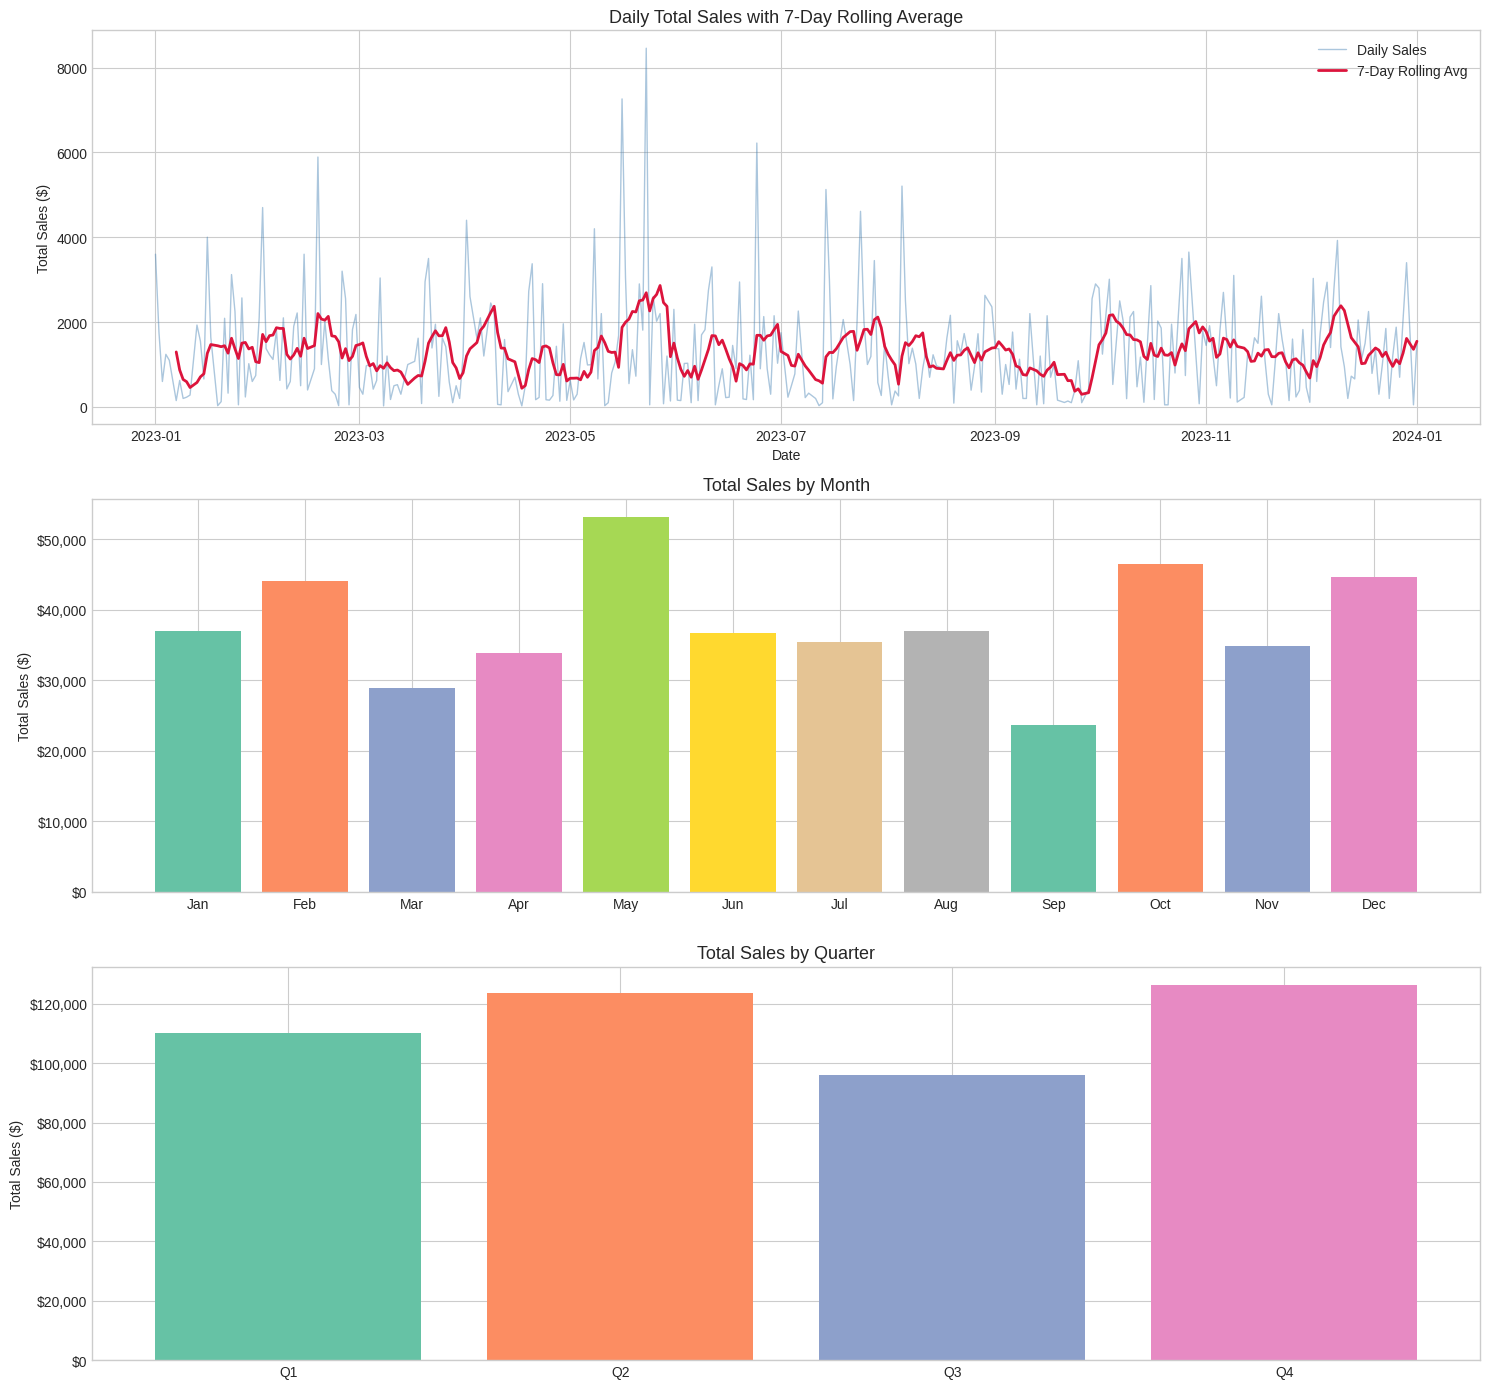

In [6]:
# Compute 7-day rolling average on daily sales for visualization
daily_sales['Rolling_7d'] = daily_sales['Daily_Total'].rolling(window=7).mean()

fig, axes = plt.subplots(3, 1, figsize=(15, 14))

# Daily Total Sales with 7-Day Rolling Average
axes[0].plot(daily_sales['Date'], daily_sales['Daily_Total'],
             color='steelblue', alpha=0.45, linewidth=1, label='Daily Sales')
axes[0].plot(daily_sales['Date'], daily_sales['Rolling_7d'],
             color='crimson', linewidth=2, label='7-Day Rolling Avg')
axes[0].set_title('Daily Total Sales with 7-Day Rolling Average', fontsize=13)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Total Sales ($)')
axes[0].legend()

# Total Sales by Month
monthly = df.groupby('MonthName')['Total Amount'].sum().reindex(month_order)
axes[1].bar(range(12), monthly.values, color=sns.color_palette('Set2', 12))
axes[1].set_xticks(range(12))
axes[1].set_xticklabels([m[:3] for m in month_order])
axes[1].set_title('Total Sales by Month', fontsize=13)
axes[1].set_ylabel('Total Sales ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Total Sales by Quarter
quarterly = df.groupby('Quarter')['Total Amount'].sum()
axes[2].bar(['Q1','Q2','Q3','Q4'], quarterly.values, color=sns.color_palette('Set2', 4))
axes[2].set_title('Total Sales by Quarter', fontsize=13)
axes[2].set_ylabel('Total Sales ($)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

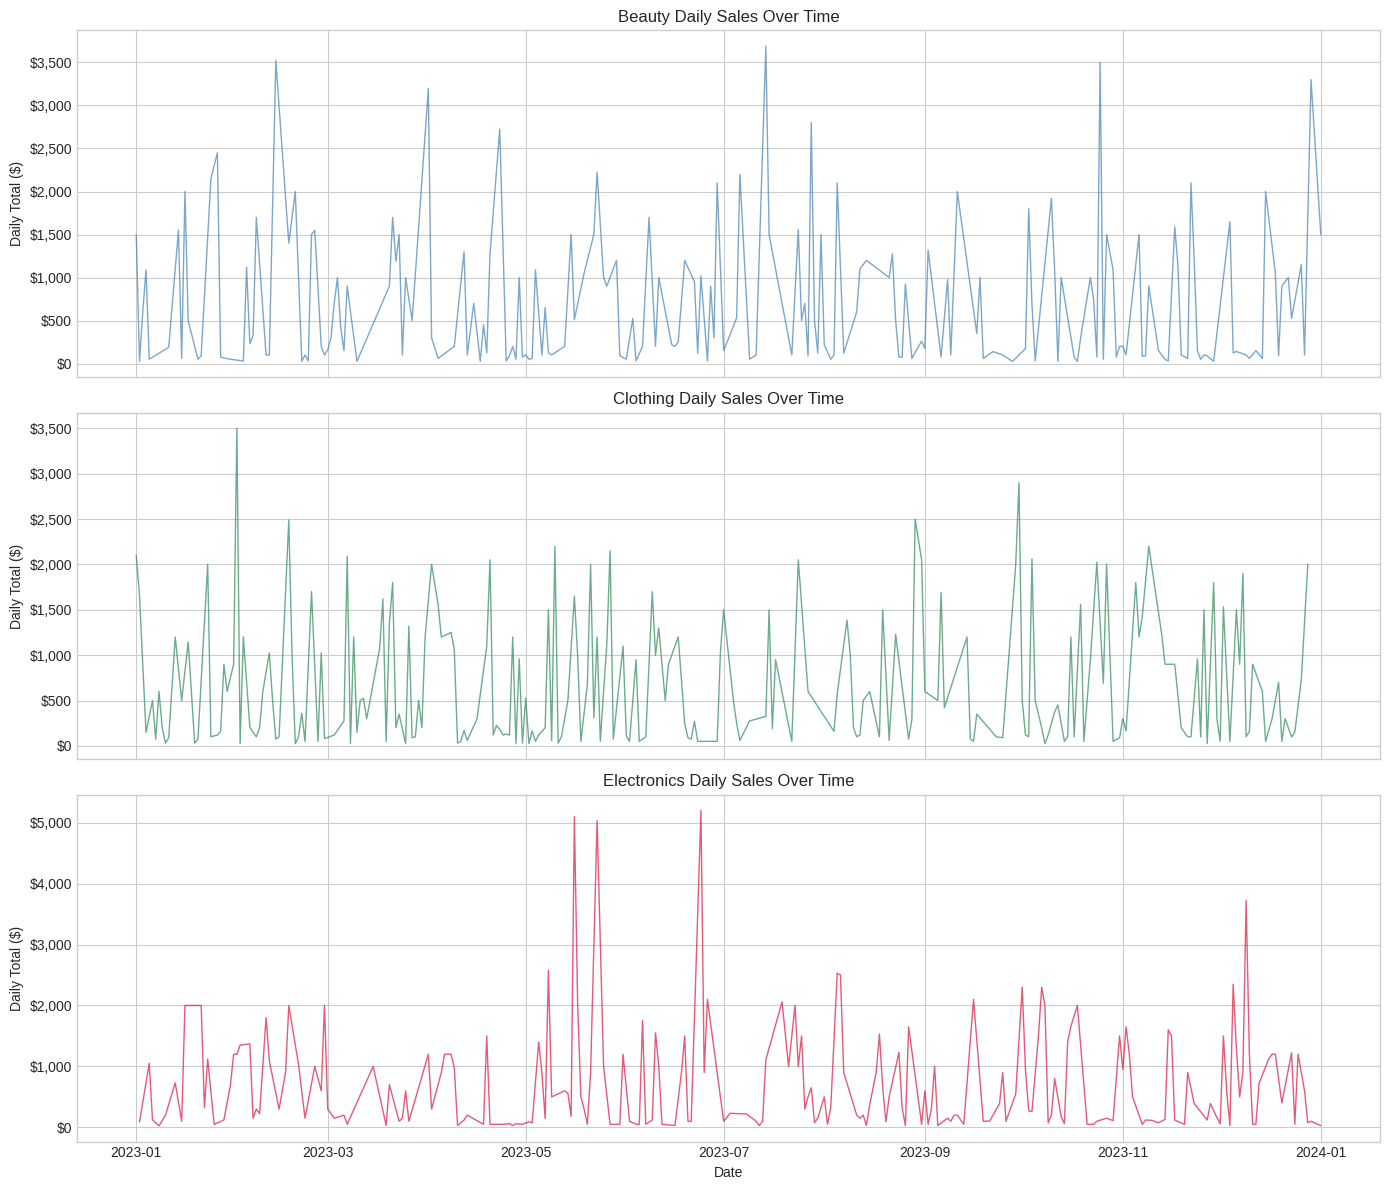

In [7]:
# Daily sales by product category
cat_month = df.groupby(['Product Category', 'Date'])['Total Amount'].sum().reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
categories = ['Beauty', 'Clothing', 'Electronics']
colors = ['steelblue', 'seagreen', 'crimson']

for ax, cat, color in zip(axes, categories, colors):
    subset = cat_month[cat_month['Product Category'] == cat]
    ax.plot(subset['Date'], subset['Total Amount'], color=color, linewidth=1, alpha=0.7)
    ax.set_title(f'{cat} Daily Sales Over Time')
    ax.set_ylabel('Daily Total ($)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

### 3b. Seasonality Heatmap: Month × Day of Week

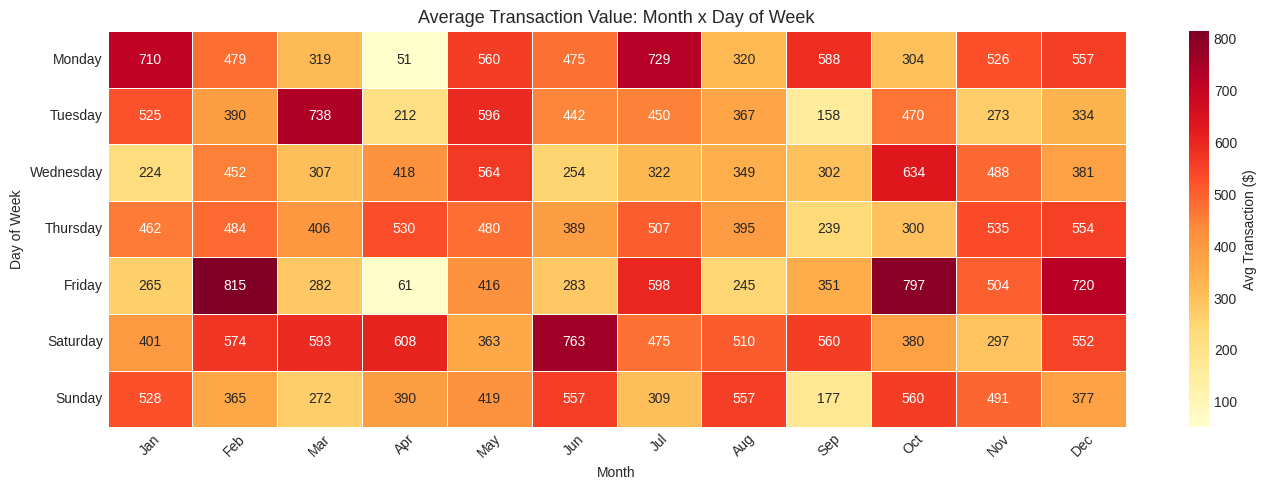


Average transaction value by day of week:
  Monday: $468
  Tuesday: $413
  Wednesday: $391
  Thursday: $440
  Friday: $445
  Saturday: $506
  Sunday: $417


In [8]:
heatmap_data = df.pivot_table(
    values='Total Amount', index='DayName', columns='MonthName', aggfunc='mean'
).reindex(index=day_order, columns=month_order)

plt.figure(figsize=(14, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.5,
            annot=True, fmt='.0f', cbar_kws={'label': 'Avg Transaction ($)'})
plt.title('Average Transaction Value: Month x Day of Week', fontsize=13)
plt.xlabel('Month')
plt.ylabel('Day of Week')
plt.xticks([i+0.5 for i in range(12)], [m[:3] for m in month_order], rotation=45)
plt.tight_layout()
plt.show()

# Average transaction value for each day of the week
print("\nAverage transaction value by day of week:")
for day in day_order:
    print(f"  {day}: ${heatmap_data.loc[day].mean():,.0f}")

### 3c. Outlier & Anomaly Detection

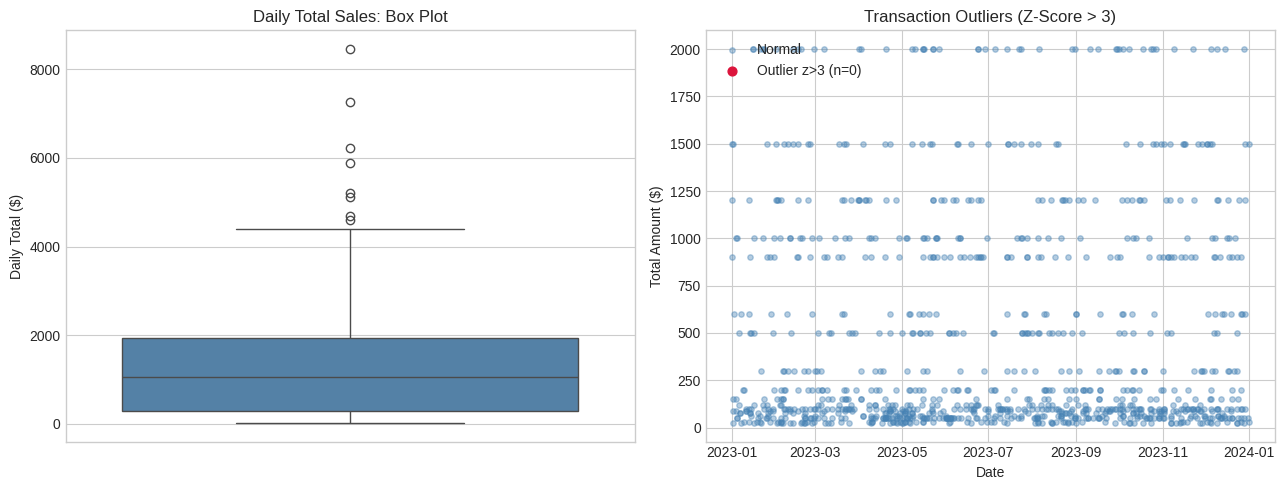

IQR upper bound for daily sales: $4,425
Days exceeding upper bound: 8
          Date  DayOfWeek  Daily_Total  Rolling_7d
29  2023-02-01          2         4700    1,709.29
44  2023-02-17          4         5890    2,200.71
127 2023-05-16          1         7260    1,875.71
134 2023-05-23          1         8455    2,691.43
166 2023-06-24          5         6220    1,688.57
183 2023-07-14          4         5125    1,180.00
191 2023-07-24          0         4610    1,565.71
203 2023-08-05          5         5205    1,197.14


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# IQR box plot on daily totals
sns.boxplot(y=daily_sales['Daily_Total'], ax=axes[0], color='steelblue')
axes[0].set_title('Daily Total Sales: Box Plot')
axes[0].set_ylabel('Daily Total ($)')

# Z-score on individual transactions, flag when |z| > 3
df['Z_Total'] = np.abs(stats.zscore(df['Total Amount']))
outliers = df[df['Z_Total'] > 3]
axes[1].scatter(df['Date'], df['Total Amount'], alpha=0.4, s=15,
                color='steelblue', label='Normal')
axes[1].scatter(outliers['Date'], outliers['Total Amount'],
                color='crimson', s=40, label=f'Outlier z>3 (n={len(outliers)})')
axes[1].set_title('Transaction Outliers (Z-Score > 3)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total Amount ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

Q1_d, Q3_d = daily_sales['Daily_Total'].quantile([0.25, 0.75])
IQR_d = Q3_d - Q1_d
upper_d = Q3_d + 1.5 * IQR_d
iqr_outlier_days = daily_sales[daily_sales['Daily_Total'] > upper_d]
print(f"IQR upper bound for daily sales: ${upper_d:,.0f}")
print(f"Days exceeding upper bound: {len(iqr_outlier_days)}")
if len(iqr_outlier_days) > 0:
    print(iqr_outlier_days.to_string())

### Advanced Anomaly Detection: Isolation Forest

Isolation Forest isolates anomalies by randomly partitioning features so anomalies require fewer splits to isolate. With the 7-day rolling average, it acts as a quantile-based detector on the smoothed daily totals. `contamination=0.05` flags the top 5% most isolated points.

Total anomalies detected: 18
          Date  DayOfWeek  Daily_Total
10  2023-01-11          2          280
69  2023-03-15          2         1000
91  2023-04-09          6         2235
98  2023-04-17          0           25
99  2023-04-18          1          500
132 2023-05-21          6         2900
133 2023-05-22          0         1810
134 2023-05-23          1         8455
136 2023-05-25          3         2600
137 2023-05-26          4         2020
138 2023-05-27          5         2200
139 2023-05-28          6           75
140 2023-05-29          0         1200
249 2023-09-24          6          390
250 2023-09-25          0         1090
251 2023-09-26          1          100
252 2023-09-28          3          425
323 2023-12-10          6         1420


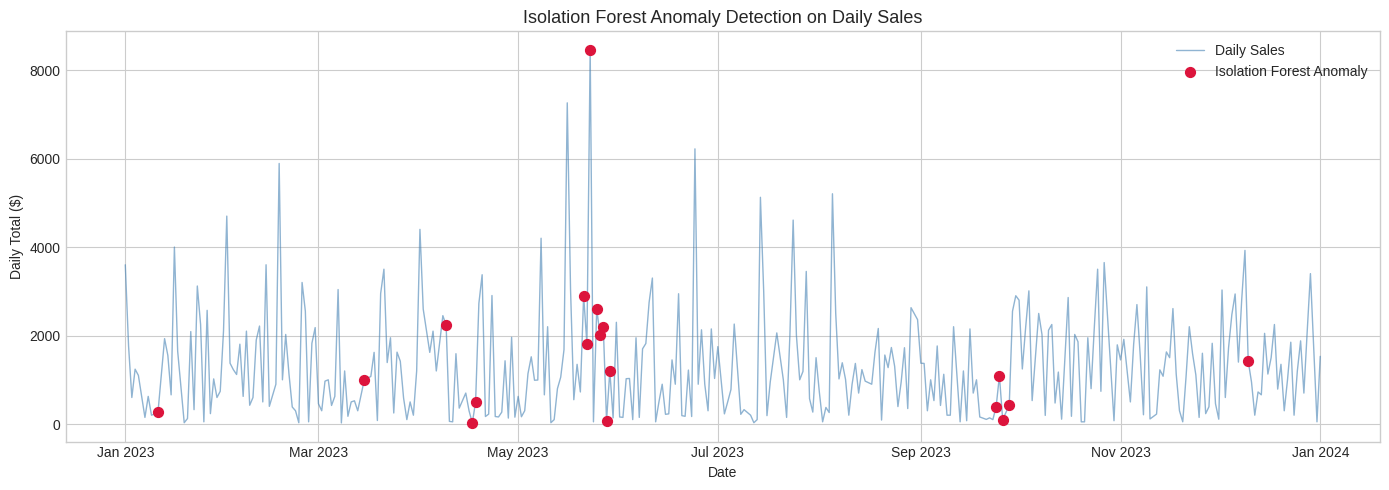

In [10]:
features = ['Rolling_7d']
iforest = IsolationForest(contamination=0.05, random_state=42)
daily_sales['anomaly_iforest'] = iforest.fit_predict(daily_sales[features].bfill())

iforest_anomalies = daily_sales[daily_sales['anomaly_iforest'] == -1]
print(f"Total anomalies detected: {iforest_anomalies.shape[0]}")
print(iforest_anomalies[['Date', 'DayOfWeek', 'Daily_Total']].to_string())

plt.figure(figsize=(14, 5))
plt.plot(daily_sales['Date'], daily_sales['Daily_Total'],
         color='steelblue', linewidth=1, alpha=0.6, label='Daily Sales')
plt.scatter(iforest_anomalies['Date'], iforest_anomalies['Daily_Total'],
            color='crimson', s=50, zorder=5, label='Isolation Forest Anomaly')
plt.title('Isolation Forest Anomaly Detection on Daily Sales', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Daily Total ($)')
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()

### 3d. Customer Demographics

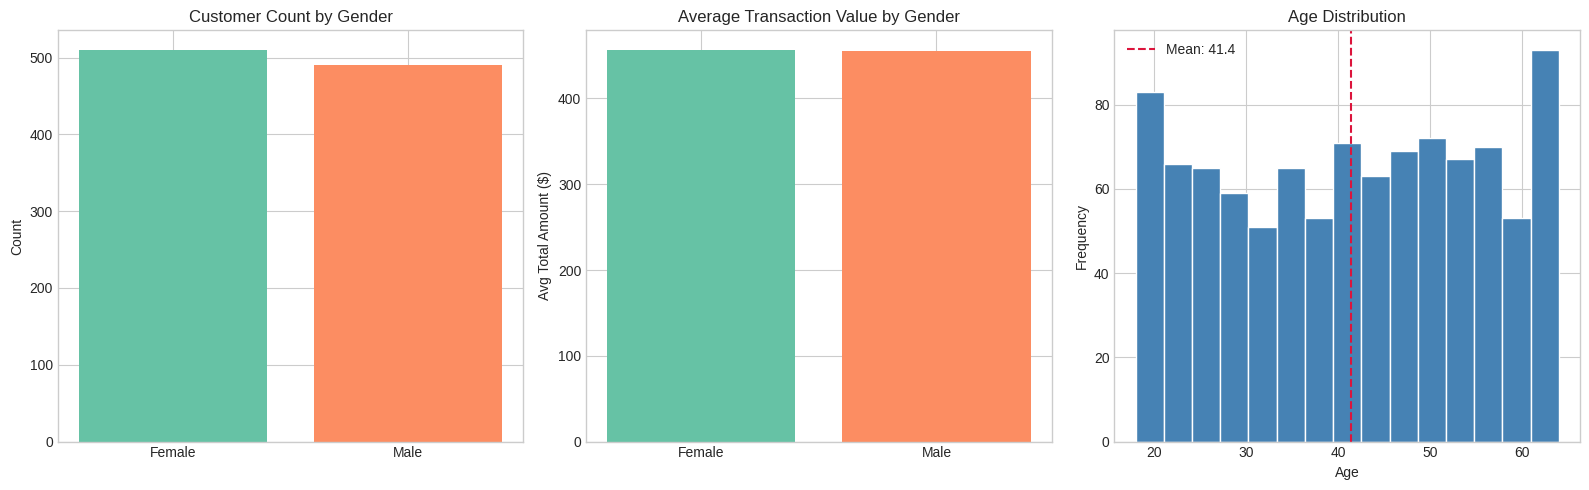

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Customer Count by Gender
gender_counts = df['Gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color=sns.color_palette('Set2', 2))
axes[0].set_title('Customer Count by Gender')
axes[0].set_ylabel('Count')

# Average Transaction Value by Gender (more informative than total spend
# given the near-even count split)
gender_avg = df.groupby('Gender')['Total Amount'].mean()
axes[1].bar(gender_avg.index, gender_avg.values, color=sns.color_palette('Set2', 2))
axes[1].set_title('Average Transaction Value by Gender')
axes[1].set_ylabel('Avg Total Amount ($)')

# Age Distribution
axes[2].hist(df['Age'], bins=15, color='steelblue', edgecolor='white')
axes[2].axvline(df['Age'].mean(), color='crimson', linestyle='--',
                label=f"Mean: {df['Age'].mean():.1f}")
axes[2].set_title('Age Distribution')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.tight_layout()
plt.show()

### 3e. Product Preferences

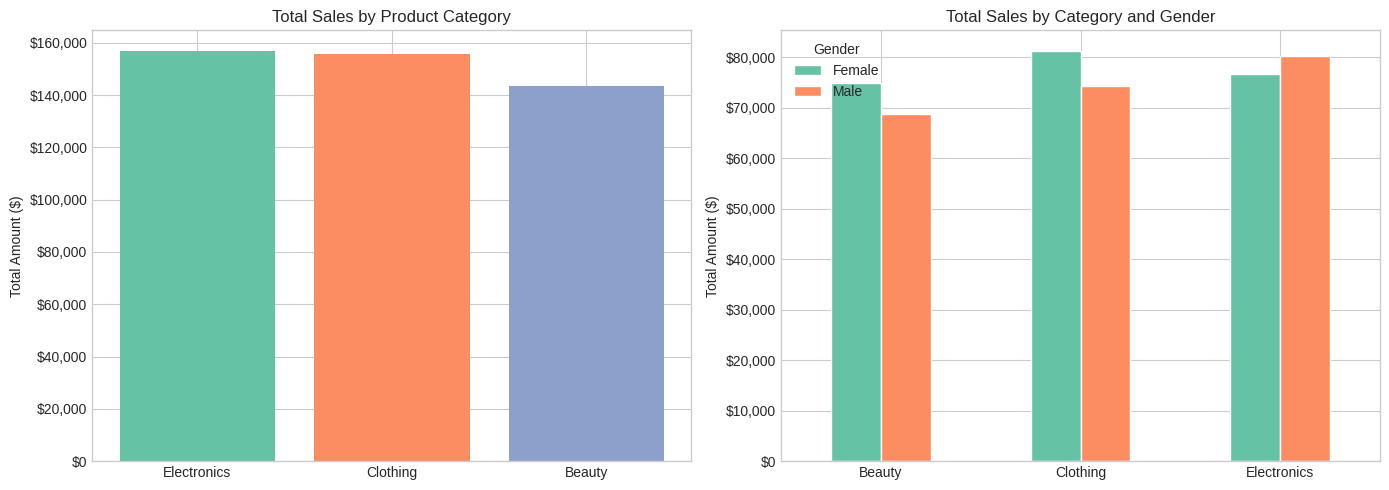

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total Sales by Product Category
cat_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
axes[0].bar(cat_sales.index, cat_sales.values, color=sns.color_palette('Set2', 3))
axes[0].set_title('Total Sales by Product Category')
axes[0].set_ylabel('Total Amount ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Total Sales by Category and Gender
cat_gender = df.groupby(['Product Category', 'Gender'])['Total Amount'].sum().unstack()
cat_gender.plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2', 2), edgecolor='white')
axes[1].set_title('Total Sales by Category and Gender')
axes[1].set_ylabel('Total Amount ($)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

### 3f. Relationships Between Variables

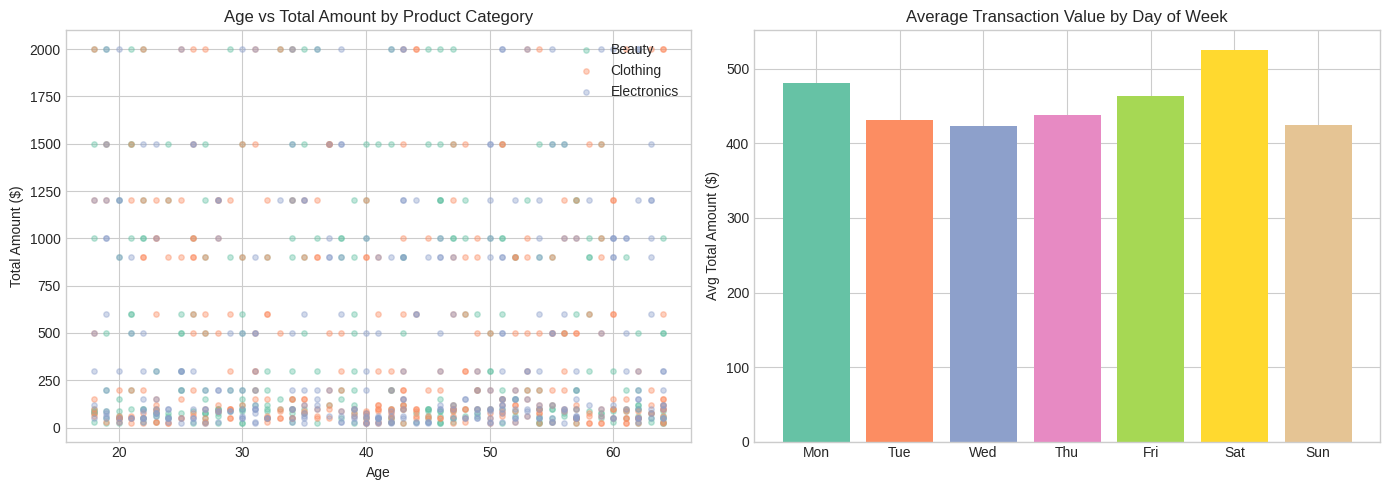

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age vs Total Amount by Product Category
for cat, grp in df.groupby('Product Category'):
    axes[0].scatter(grp['Age'], grp['Total Amount'], alpha=0.4, s=15, label=cat)
axes[0].set_title('Age vs Total Amount by Product Category')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Total Amount ($)')
axes[0].legend()

# Average Transaction Value by Day of Week
dow_spend = df.groupby('DayName')['Total Amount'].mean().reindex(day_order)
axes[1].bar(range(7), dow_spend.values, color=sns.color_palette('Set2', 7))
axes[1].set_xticks(range(7))
axes[1].set_xticklabels([d[:3] for d in day_order])
axes[1].set_title('Average Transaction Value by Day of Week')
axes[1].set_ylabel('Avg Total Amount ($)')

plt.tight_layout()
plt.show()

**Findings - Step 3:**
- Q4 is the strongest quarter; Q3 is the weakest. Monthly peaks fall in May and Nov/Dec.
- Saturdays show the highest average transaction value (506), followed by Monday (468). Wednesday is the lowest (391).
- 8 days exceeded the IQR upper bound of 4,425 on daily totals, with spikes concentrated in Feb, May, Jun, and Jul/Aug.
- Isolation Forest flagged 18 anomalous days at contamination=0.05, capturing both unusually high sales days (e.g. May 23: 8,455) and unusually low days (e.g. Apr 17: 25, May 28: 75).
- Gender split is near-even; average transaction value is similarly balanced between male and female customers.
- Electronics and Clothing lead total revenue; Beauty has comparable transaction volume but lower average value per transaction.
- No linear relationship between age and total amount spent.

---
## Step 4 - Feature Engineering

Create meaningful new features from EDA insights: binary flags for high-revenue periods, rolling and exponentially weighted moving averages on daily aggregated sales, and a high-spender demographic profile.

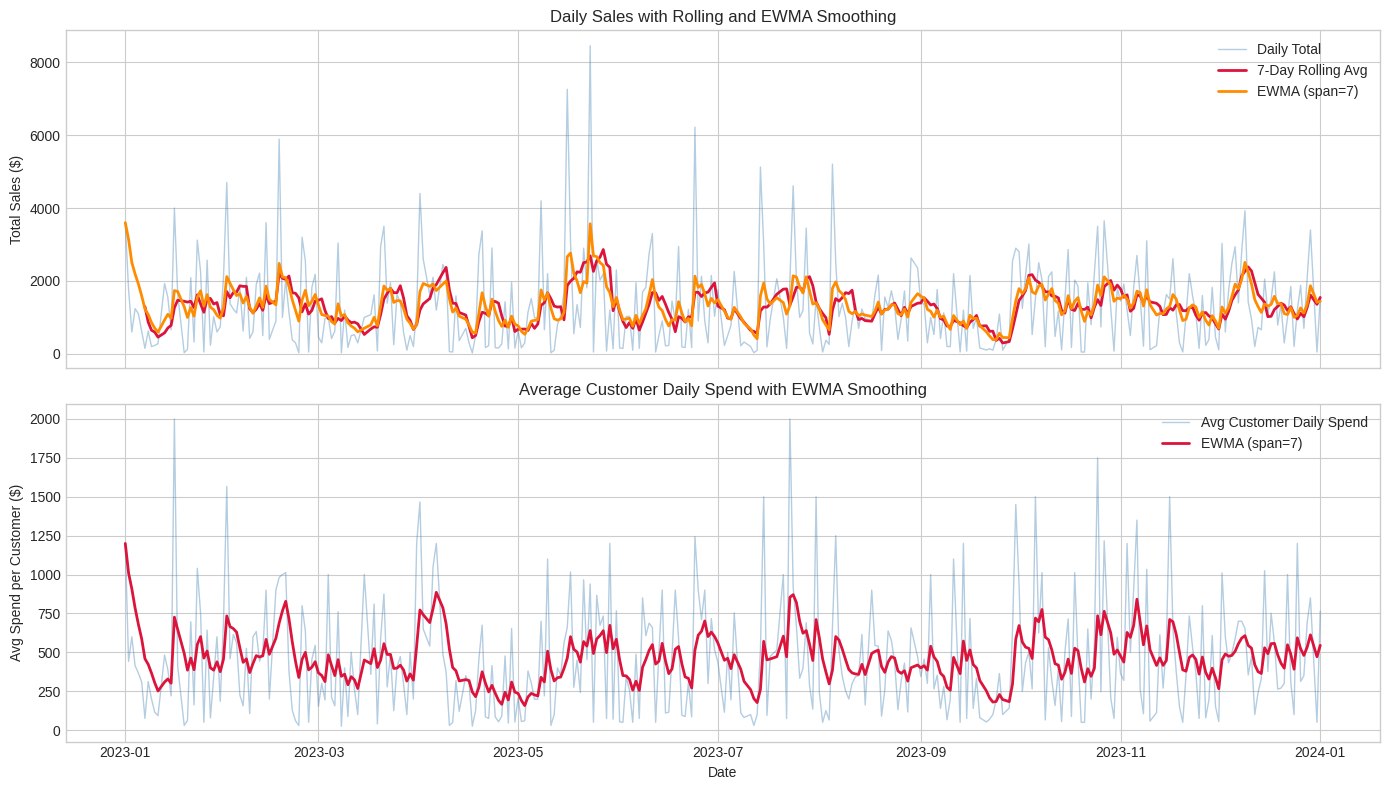

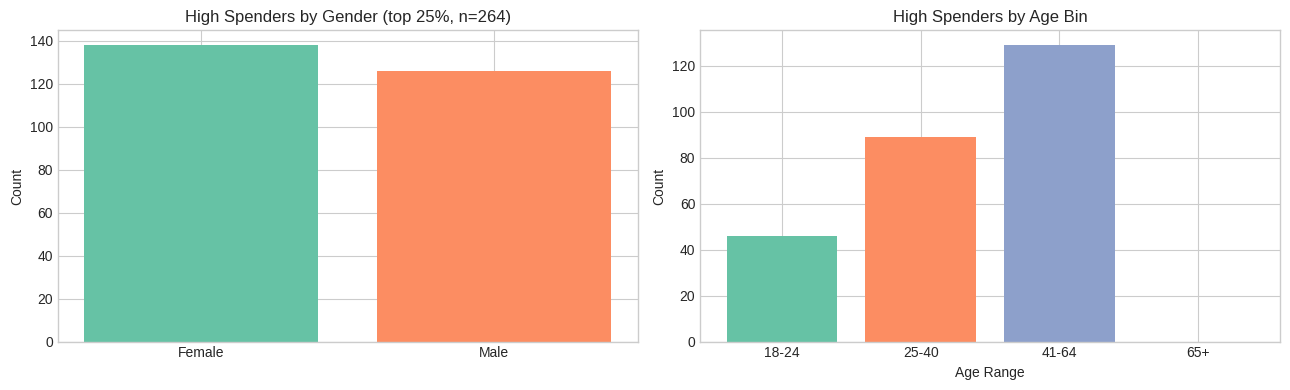

High spender threshold (75th percentile): $900

By Gender:
Gender
Female    138
Male      126
dtype: int64

By Age Bin:
Age_Bin
18-24     46
25-40     89
41-64    129
65+        0
dtype: int64


In [14]:
# Binary flags from EDA insights
df['Is_Weekend'] = (df['DayOfWeek'] >= 5).astype(int)
df['Is_Q4']      = (df['Quarter'] == 4).astype(int)
# Note: Year is omitted because all transactions occur in 2023.

# Rolling and EWMA features on daily aggregated sales
rolling_df = daily_sales[['Date', 'Daily_Total', 'Rolling_7d']].copy()
rolling_df['EWMA_7d'] = rolling_df['Daily_Total'].ewm(span=7, adjust=False).mean()

# Average customer spend per day
daily_transaction_count = df.groupby('Date')['Transaction ID'].count()
rolling_df['AVG_Customer_Daily_Spend'] = rolling_df['Daily_Total'] / daily_transaction_count.values
rolling_df['EWMA_ACDS'] = rolling_df['AVG_Customer_Daily_Spend'].ewm(span=7, adjust=False).mean()

# Plot the rolling features
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(rolling_df['Date'], rolling_df['Daily_Total'],
             color='steelblue', alpha=0.4, linewidth=1, label='Daily Total')
axes[0].plot(rolling_df['Date'], rolling_df['Rolling_7d'],
             color='crimson', linewidth=2, label='7-Day Rolling Avg')
axes[0].plot(rolling_df['Date'], rolling_df['EWMA_7d'],
             color='darkorange', linewidth=2, label='EWMA (span=7)')
axes[0].set_title('Daily Sales with Rolling and EWMA Smoothing')
axes[0].set_ylabel('Total Sales ($)')
axes[0].legend()

axes[1].plot(rolling_df['Date'], rolling_df['AVG_Customer_Daily_Spend'],
             color='steelblue', alpha=0.4, linewidth=1, label='Avg Customer Daily Spend')
axes[1].plot(rolling_df['Date'], rolling_df['EWMA_ACDS'],
             color='crimson', linewidth=2, label='EWMA (span=7)')
axes[1].set_title('Average Customer Daily Spend with EWMA Smoothing')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Avg Spend per Customer ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

# High Spender Demographic: top 25% of transactions by Total Amount
spender_threshold = df['Total Amount'].quantile(0.75)
high_spender_df = df[df['Total Amount'] >= spender_threshold].copy()

age_bins = [18, 25, 41, 65, 100]
age_labels = ['18-24', '25-40', '41-64', '65+']
high_spender_df['Age_Bin'] = pd.cut(high_spender_df['Age'], bins=age_bins,
                                     labels=age_labels, right=False)

high_spender_gender = high_spender_df.groupby('Gender').size()
high_spender_age = high_spender_df.groupby('Age_Bin', observed=False).size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(high_spender_gender.index, high_spender_gender.values,
            color=sns.color_palette('Set2', 2))
axes[0].set_title(f'High Spenders by Gender (top 25%, n={len(high_spender_df)})')
axes[0].set_ylabel('Count')

axes[1].bar(high_spender_age.index.astype(str), high_spender_age.values,
            color=sns.color_palette('Set2', 4))
axes[1].set_title('High Spenders by Age Bin')
axes[1].set_xlabel('Age Range')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"High spender threshold (75th percentile): ${spender_threshold:,.0f}")
print(f"\nBy Gender:\n{high_spender_gender}")
print(f"\nBy Age Bin:\n{high_spender_age}")

**Reasoning - Feature Engineering:**

* **Is_Weekend, Is_Q4** encode the strongest EDA patterns (Saturday spend premium, Q4 revenue peak) as binary signals.
* **Rolling_7d** is a 7-day average on daily aggregated totals. First used in Step 3 to smooth the trend line for visualization, then carried forward as a feature on the daily-aggregated data.
* **EWMA_7d** is an exponentially weighted moving average (span=7); recent days are weighted more heavily than older days, so the influence of past sales decays over time. Ideally this feature would be applied at the customer level to model recent customer behavior, but this dataset contains no repeat customers, so it is applied to daily aggregated sales instead.
* **AVG_Customer_Daily_Spend** and **EWMA_ACDS** give a per-customer view of daily spending, normalized by the number of transactions on each day.
* **High spender demographic profile** identifies which gender and age groups appear most often in the top 25% of transactions by value. This is descriptive rather than predictive but useful for targeted marketing recommendations.

---
## Step 5 - Clean and Transform Data

Handle missing data, outliers, and skewness using log transformation. The IQR method is also applied to confirm the discrete price-tier structure of the dataset.

### 5a. Data Integrity Check

In [15]:
# Verify Total Amount = Quantity x Price per Unit for every row
mismatches = df[df['Total Amount'] != df['Quantity'] * df['Price per Unit']]
print(f"Rows where Total Amount does not equal Quantity x Price per Unit: {len(mismatches)}")
if len(mismatches) == 0:
    print("All Total Amount values are internally consistent.")
else:
    print(mismatches[['Transaction ID','Quantity','Price per Unit','Total Amount']])

Rows where Total Amount does not equal Quantity x Price per Unit: 0
All Total Amount values are internally consistent.


### 5b. Skewness & Log Transformation

Skewness before: 1.38
Skewness after : 0.26


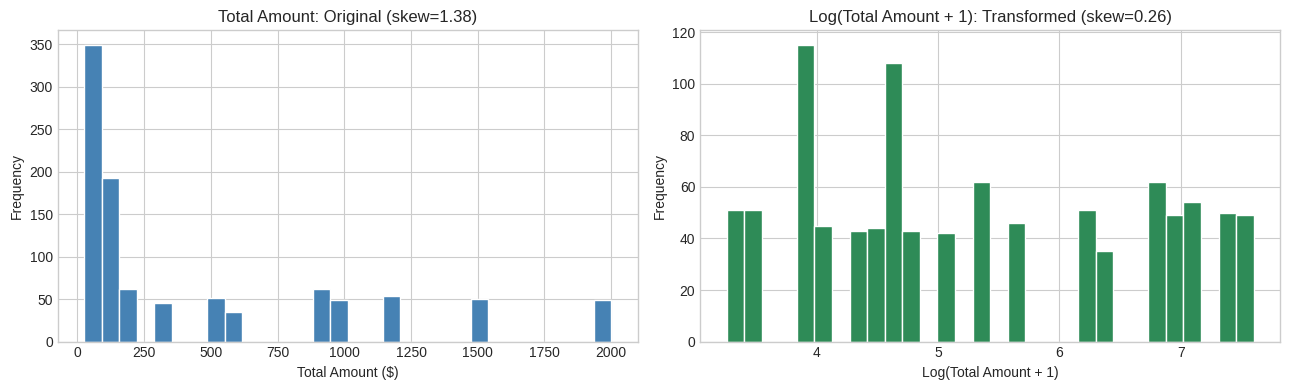

In [16]:
skew_before = df['Total Amount'].skew()
df['Log_Total_Amount'] = np.log1p(df['Total Amount'])
skew_after = df['Log_Total_Amount'].skew()

print(f"Skewness before: {skew_before:.2f}")
print(f"Skewness after : {skew_after:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['Total Amount'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title(f'Total Amount: Original (skew={skew_before:.2f})')
axes[0].set_xlabel('Total Amount ($)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['Log_Total_Amount'], bins=30, color='seagreen', edgecolor='white')
axes[1].set_title(f'Log(Total Amount + 1): Transformed (skew={skew_after:.2f})')
axes[1].set_xlabel('Log(Total Amount + 1)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 5c. Treat Outliers in Total Amount

In [17]:
Q1 = df['Total Amount'].quantile(0.25)
Q3 = df['Total Amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"IQR lower bound : ${lower_bound:,.0f}")
print(f"IQR upper bound : ${upper_bound:,.0f}")
print(f"Values below lower bound : {(df['Total Amount'] < lower_bound).sum()}")
print(f"Values above upper bound : {(df['Total Amount'] > upper_bound).sum()}")
print()
print("No IQR outliers at transaction level. Discrete price tiers mean high values")
print("like $2,000 are legitimate. Daily aggregated outliers (Step 3c) are more meaningful.")

IQR lower bound : $-1,200
IQR upper bound : $2,160
Values below lower bound : 0
Values above upper bound : 0

No IQR outliers at transaction level. Discrete price tiers mean high values
like $2,000 are legitimate. Daily aggregated outliers (Step 3c) are more meaningful.


**Findings - Step 5:**
- All `Total Amount` values equal `Quantity × Price per Unit`, confirming no data errors.
- Skewness reduced from 1.38 to 0.26 after log transform. Use `Log_Total_Amount` as the target for linear or regularized models.
- IQR bounds: lower -1,200, upper 2,160. No values fall outside either bound, which is expected given the discrete price-tier structure. The maximum transaction value of 2,000 sits just within the upper fence.
- The Total Amount histogram clearly shows the five discrete price tiers (25, 30, 50, 300, 500) as separate spikes, which explains why distribution-based methods like IQR find no outliers at the transaction level.

---
## Step 6 - Evaluate Features

Use correlation analysis and PCA to identify the most relevant features for a potential model.

### 6a. Correlation Heatmap

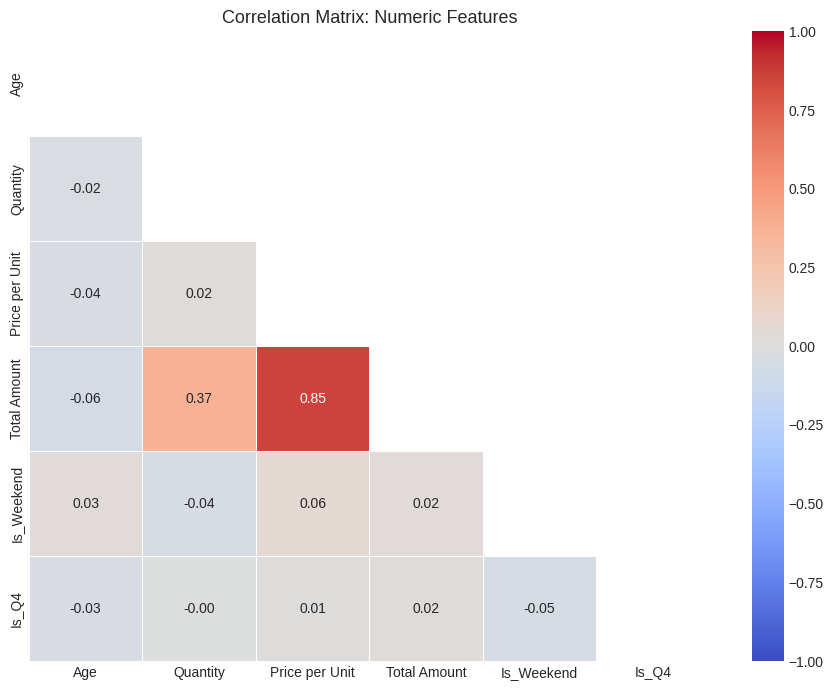

In [18]:
numeric_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount', 'Is_Weekend', 'Is_Q4']
corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
plt.grid(False)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix: Numeric Features', fontsize=13)
plt.tight_layout()
plt.show()

### 6b. Feature Importance Ranking

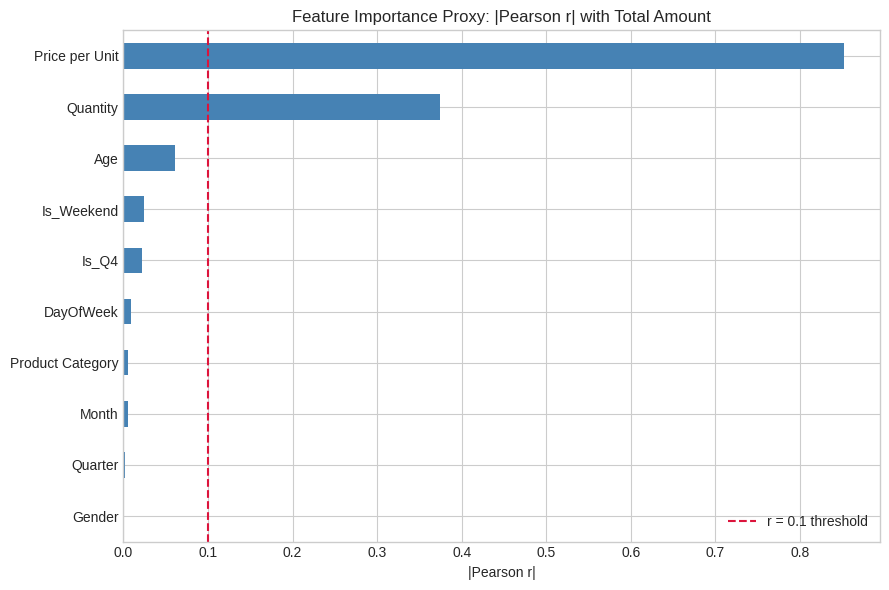


Ranking (highest to lowest):
Price per Unit     0.85
Quantity           0.37
Age                0.06
Is_Weekend         0.02
Is_Q4              0.02
DayOfWeek          0.01
Product Category   0.01
Month              0.01
Quarter            0.00
Gender             0.00


In [19]:
df_enc = df.copy()
for col in ['Gender', 'Product Category']:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col])

feature_cols = ['Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit',
                'Month', 'Quarter', 'DayOfWeek', 'Is_Weekend', 'Is_Q4']

correlations = (
    df_enc[feature_cols]
    .corrwith(df_enc['Total Amount'])
    .abs()
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 6))
correlations.plot(kind='barh', color='steelblue')
plt.title('Feature Importance Proxy: |Pearson r| with Total Amount', fontsize=12)
plt.xlabel('|Pearson r|')
plt.axvline(0.1, color='crimson', linestyle='--', label='r = 0.1 threshold')
plt.legend()
plt.tight_layout()
plt.show()

print("\nRanking (highest to lowest):")
print(correlations.sort_values(ascending=False).to_string())

### 6c. PCA / Principal Component Analysis
Reduces features into uncorrelated components. Reveals underlying data structure and redundant features.

In [20]:
pca_features = ['Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit','Month', 'Quarter', 'DayOfWeek', 'Is_Weekend', 'Is_Q4']

X = df_enc[pca_features].dropna()

# Standardize - PCA is scale-sensitive
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit full PCA to inspect all components
pca_full = PCA(n_components=None, random_state=42)
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1

print(f"Components for 80% variance: {n_components_80}")
print(f"Components for 95% variance: {n_components_95}")
for i, v in enumerate(pca_full.explained_variance_ratio_):
    print(f"  PC{i+1}: {v:.3f} ({cumulative_variance[i]:.3f} cumulative)")

Components for 80% variance: 6
Components for 95% variance: 8
  PC1: 0.270 (0.270 cumulative)
  PC2: 0.181 (0.451 cumulative)
  PC3: 0.108 (0.559 cumulative)
  PC4: 0.102 (0.661 cumulative)
  PC5: 0.099 (0.760 cumulative)
  PC6: 0.095 (0.856 cumulative)
  PC7: 0.093 (0.949 cumulative)
  PC8: 0.028 (0.977 cumulative)
  PC9: 0.020 (0.997 cumulative)
  PC10: 0.003 (1.000 cumulative)


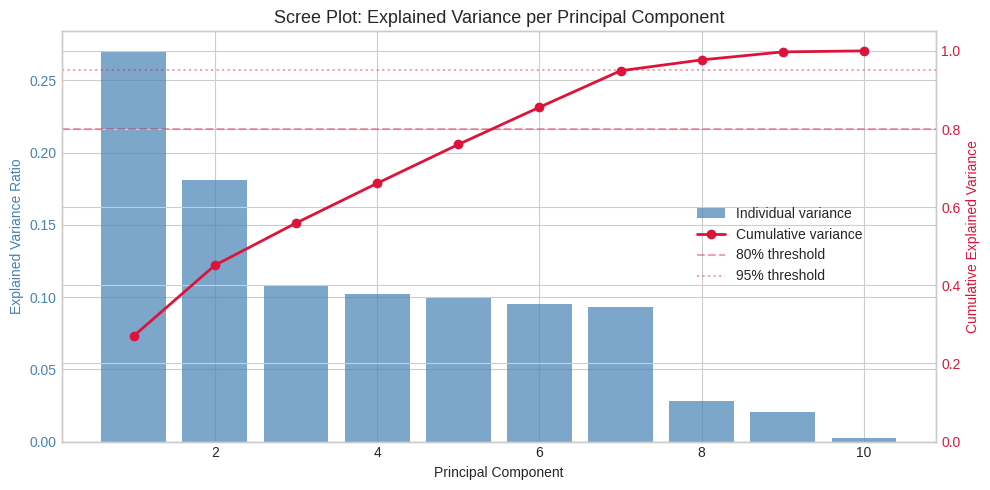

In [21]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
        pca_full.explained_variance_ratio_,
        color='steelblue', alpha=0.7, label='Individual variance')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance,
         color='crimson', marker='o', linewidth=2, label='Cumulative variance')
ax2.set_ylabel('Cumulative Explained Variance', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.set_ylim(0, 1.05)
ax2.axhline(0.80, color='crimson', linestyle='--', alpha=0.4, label='80% threshold')
ax2.axhline(0.95, color='crimson', linestyle=':', alpha=0.4, label='95% threshold')

plt.title('Scree Plot: Explained Variance per Principal Component', fontsize=13)
fig.legend(loc='center right', bbox_to_anchor=(0.88, 0.5))
plt.tight_layout()
plt.show()

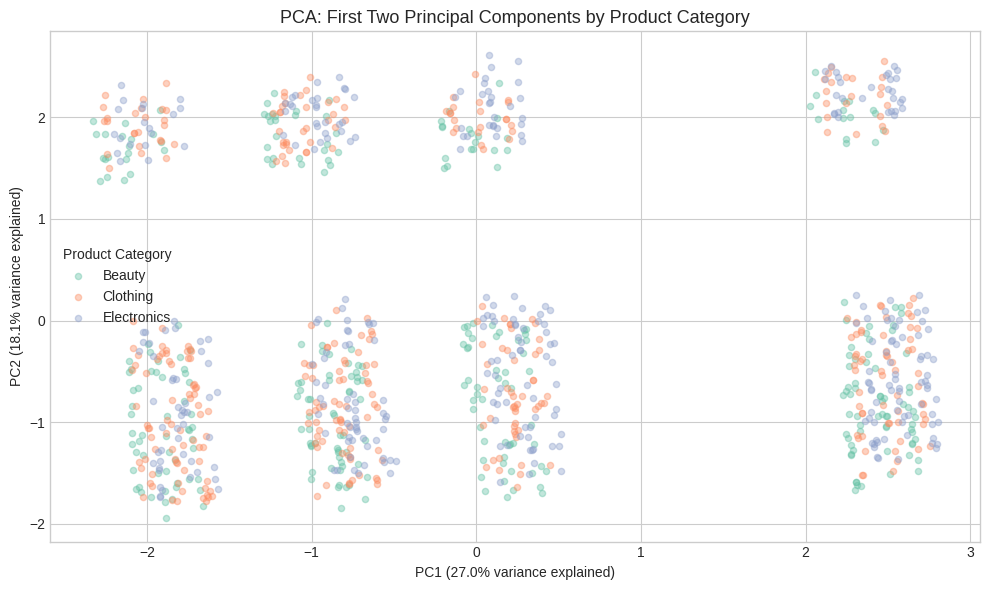

In [22]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
pca_df['Product Category'] = df_enc['Product Category'].values[:len(pca_df)]
category_map = dict(enumerate(df['Product Category'].unique()))
pca_df['Category Label'] = pca_df['Product Category'].map(category_map)

plt.figure(figsize=(10, 6))
for label, grp in pca_df.groupby('Category Label'):
    plt.scatter(grp['PC1'], grp['PC2'], alpha=0.4, s=20, label=label)
plt.title('PCA: First Two Principal Components by Product Category', fontsize=13)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance explained)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance explained)')
plt.legend(title='Product Category')
plt.tight_layout()
plt.show()

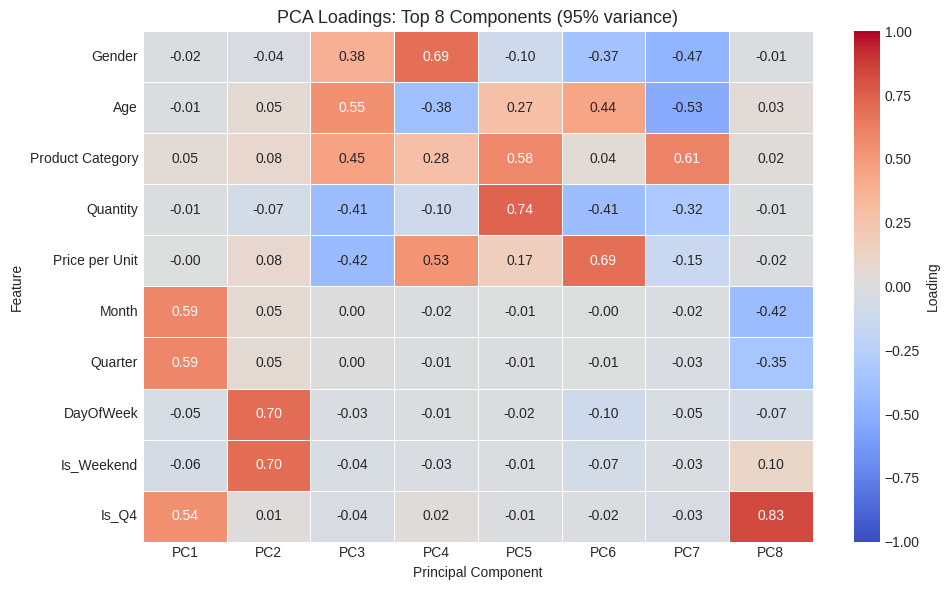


Dominant feature per component:
  PC1: Quarter (+0.59)
  PC2: Is_Weekend (+0.70)
  PC3: Age (+0.55)
  PC4: Gender (+0.69)
  PC5: Quantity (+0.74)
  PC6: Price per Unit (+0.69)
  PC7: Product Category (+0.61)
  PC8: Is_Q4 (+0.83)


In [23]:
pca_final = PCA(n_components=n_components_95, random_state=42)
pca_final.fit(X_scaled)

loadings = pd.DataFrame(
    pca_final.components_.T,
    index=pca_features,
    columns=[f'PC{i+1}' for i in range(n_components_95)]
)

plt.figure(figsize=(10, 6))
plt.grid(False)
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, cbar_kws={'label': 'Loading'})
plt.title(f'PCA Loadings: Top {n_components_95} Components (95% variance)', fontsize=13)
plt.xlabel('Principal Component')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nDominant feature per component:")
for col in loadings.columns:
    top = loadings[col].abs().idxmax()
    print(f"  {col}: {top} ({loadings[col][top]:+.2f})")

**Findings - Step 6:**

* Price per Unit is by far the strongest predictor of Total Amount (r=0.85), driven by the dataset's discrete price tiers.
* Quantity shows moderate correlation (r=0.37).
* All remaining features have near-zero correlation with Total Amount individually: Age (0.06), Is_Weekend (0.02), Is_Q4 (0.02), DayOfWeek (0.01), Product Category (0.01), Month (0.01), Quarter (0.00), Gender (0.00).
* Temporal and categorical features are effectively uncorrelated with Total Amount at the transaction level. They may add signal in an aggregated daily or weekly forecasting model but do not predict individual transaction value. (This finding is the motivating premise for Project 2.)
* PCA shows variance is spread evenly across components: PC1 explains 27.0%, PC2 explains 18.1%, and no single component dominates. 6 components are needed for 80% variance, 8 for 95%.
* PC1 is driven by Month, Quarter, and Is_Q4, capturing seasonality.
* PC2 is driven by DayOfWeek and Is_Weekend, capturing day-of-week patterns.
* PC4 is driven by Quantity and Price per Unit, capturing transaction value.
* The 2D PCA scatter shows complete category overlap across PC1 and PC2, meaning product category cannot be separated from these features alone.
* **Recommended feature set:** Price per Unit and Quantity are the only features with meaningful individual correlation to Total Amount. Temporal features should be evaluated in an aggregated forecasting context rather than transaction-level prediction.

## Step 7 - Summary: Findings, Insights, and Recommendations

### Key Findings

**Data Quality**
* No missing values, no duplicates. All Total Amount values equal Quantity × Price per Unit.
* Total Amount is right-skewed (1.38); log transform reduces skewness to 0.26.

**Sales Trends and Seasonality**
* Q4 is the strongest quarter; Q3 is the weakest. Monthly peaks fall in May and Nov/Dec.
* Saturday has the highest average transaction value (506); Wednesday has the lowest (391).
* 8 days exceeded the IQR upper bound for daily sales (4,425), concentrated in Feb, May, Jun, and Jul/Aug.
* Isolation Forest flagged 18 anomalous days, including both high spikes (May 23: 8,455) and low troughs (Apr 17: 25).

**Customer Demographics**
* Near-even gender split; average transaction value is similarly balanced.
* Age broadly distributed (18 to 64, mean 41), and spend is not age-driven.
* No repeat customers in the dataset, so customer-level segmentation and behavioral analysis are not possible with this data alone.

**Products**
* Electronics and Clothing lead total revenue. Beauty has similar transaction volume but lower average value per transaction.
* Price per Unit takes 5 fixed values (25, 30, 50, 300, 500). This discrete structure appears in all correlation and PCA results.

**Features**
* Price per Unit (r=0.85) and Quantity (r=0.37) are the only features with meaningful correlation to Total Amount at the transaction level.
* All temporal and categorical features have near-zero individual correlation.

---

### Business Recommendations

* **Inventory:** Stock Electronics and Clothing ahead of Q4 and May. Reduce in Q3.
* **Weekend promotions:** Saturday drives the highest average spend (506) and should be targeted with flash sales or exclusive offers.
* **Beauty:** Bundle with Clothing or introduce higher-priced premium items to close the revenue gap.
* **Q3 stimulus:** Summer clearance or back-to-school campaigns to lift the slow period.
* **Anomaly tracking:** Isolation Forest flags both unusually high and unusually low sales days, so keep a record of promotions, holidays, and store closures so flagged days can be explained and acted on.
* **Customer segmentation** is not possible with this dataset because no repeat purchase history exists to build behavioral segments. Additional data such as purchase frequency and customer lifetime value would be needed to identify segments worth targeting.

---

### Additional Data Needed

* Profit margins per product: revenue rankings may not reflect profitability.
* Marketing spend and campaign calendar: needed to explain anomalous sales days.
* Returns and refunds: gross sales may overstate actual revenue.
* How customers found the business (social media, search, word of mouth): to understand which sources drive the highest-value transactions.
* Geographic data: to identify regional demand patterns.